In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


In [44]:
SEARCH_QUERY = "sony wireless over-ear noise cancelling headphones"
NUM_PAGES = 10
OUTPUT_FILE = "amazon_wireless_headphones.csv"

def clean_rating(text):
    if not text:
        return None
    match = re.search(r"\d+\.\d+", text)
    return float(match.group()) if match else None

options = Options()
options.add_argument("--headless=new")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 15)

rows = []

try:
    for page in range(1, NUM_PAGES + 1):
        #url = f"https://www.amazon.com/s?k=wireless+headphones&rh=n%3A21514463011%2Cp_123%3A233043%257C264616%257C325772&dc&crid=37RAF0SVWP0ZZ&qid=1776023787&rnid=85457740011&sprefix=%2Caps%2C177&ref=sr_nr_p_123_4&ds=v1%3AaS7xNxv3ETbq0rBMp0a1QOxUuJUGO4XFffw2gLNIQOY"
        url = f"https://www.amazon.com/s?k={SEARCH_QUERY.replace(' ', '+')}&page={page}"
        driver.get(url)

        # print("URL:", driver.current_url)
        # print("TITLE:", driver.title)
        # print("CARDS FOUND:", len(driver.find_elements(By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')))
        # print(driver.page_source[:1500])

        wait.until(
            EC.presence_of_all_elements_located(
                (By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')
            )
        )

        time.sleep(2)
        product_cards = driver.find_elements(By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')

        for card in product_cards:
            title = None
            rating = None
            review_count = None
            price = None

            try:
                title = card.find_element(By.CSS_SELECTOR, "h2 span").text.strip()
            except:
                pass

            rating_text = None
            selectors_to_try = [
                "span.a-icon-alt",
                "i span.a-icon-alt",
                '[aria-label*="out of 5 stars"]',
                '[aria-label*="stars"]'
            ]

            for sel in selectors_to_try:
                try:
                    el = card.find_element(By.CSS_SELECTOR, sel)
                    rating_text = el.text.strip() or el.get_attribute("aria-label")
                    if rating_text:
                        break
                except:
                    continue

            rating = clean_rating(rating_text)

            try:
                review_tag = card.find_element(
                    By.CSS_SELECTOR,
                    'span.a-size-mini.puis-normal-weight-text.s-underline-text'
                )
                
                review_text = review_tag.text.strip()

                review_text = review_text.replace("(", "").replace(")", "").lower()

                if "k" in review_text:
                    number = float(review_text.replace("k", ""))
                    review_count = int(number * 1000)
                else:
                    review_count = int(review_text.replace(",", ""))

            except:
                pass

            try:
                whole = card.find_element(By.CSS_SELECTOR, ".a-price-whole").text
                fraction = card.find_element(By.CSS_SELECTOR, ".a-price-fraction").text
                
                price = float(f"{whole}.{fraction}")

            except:
                pass
        

            if title:
                rows.append({
                    "title": title,
                    "rating": rating,
                    "number of reviews": review_count,
                    "Price": price,
                    "page": page,
                    "source": "Amazon"
                })

            

        time.sleep(2)

finally:
    driver.quit()

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved {len(df)} rows to {OUTPUT_FILE}")


Saved 160 rows to amazon_wireless_headphones.csv


In [45]:
df = pd.read_csv("amazon_wireless_headphones.csv")
df.head()

,title,rating,number of reviews,Price,page,source
0,Sony,4.4,15000.0,NaN,1,Amazon
1,Sony,4.4,15000.0,98.0,1,Amazon
2,Sony,4.3,3000.0,NaN,1,Amazon
3,Sony,4.4,15000.0,98.0,1,Amazon
4,Sony,4.4,1600.0,98.0,1,Amazon


In [46]:
df.shape

(160, 6)

In [47]:
display(pd.DataFrame(df.dtypes.astype(str), columns=['dtype']).reset_index().rename(columns={'index':'column'}))

,column,dtype
0,title,object
1,rating,float64
2,number of reviews,float64
3,Price,float64
4,page,int64
5,source,object


In [48]:
total_rows = df.shape[0]
null_counts = df.isnull().sum()
result = pd.DataFrame({
    "column": null_counts.index,
    "null_count": null_counts.values
})
result["null_percent"] = (result["null_count"] / total_rows * 100).round(2)
result["has_null"] = result["null_count"] > 0
display(result)

,column,null_count,null_percent,has_null
0,title,0,0.00,False
1,rating,6,3.75,True
2,number of reviews,6,3.75,True
3,Price,19,11.88,True
4,page,0,0.00,False
5,source,0,0.00,False


In [49]:
# show all rows where rating is null, excluding the rating column
null_rating_df = df[df["rating"].isna()].loc[:, df.columns != "rating"].reset_index(drop=True)
display(null_rating_df.head(1)['title'])

0    Sony WH-CH720N/P Bluetooth Wireless Noise-Canc...
Name: title, dtype: object

In [50]:
df_subset = df[(df["Price"] > 50) & (df["Price"] < 100)]
df_subset.shape

(35, 6)

In [51]:
df_subset.head(36)

,title,rating,number of reviews,Price,page,source
1,Sony,4.4,15000.0,98.00,1,Amazon
3,Sony,4.4,15000.0,98.00,1,Amazon
4,Sony,4.4,1600.0,98.00,1,Amazon
5,Sony,4.5,1300.0,98.00,1,Amazon
14,Sony,4.7,27800.0,98.00,1,Amazon
17,TAGRY,5.0,120.0,59.98,2,Amazon
18,Sony WH-CH720N Noise Canceling Wireless Headph...,4.4,328.0,73.00,2,Amazon
20,Hybrid Active Noise Cancelling Headphones 120H...,5.0,76.0,89.99,2,Amazon
23,Sony WH-CH720N/P Bluetooth Wireless Noise-Canc...,NaN,NaN,59.99,2,Amazon
27,Sony - WH-CH720N Wireless Noise Canceling Head...,NaN,NaN,59.99,2,Amazon


In [52]:
df_sony = df[df["title"].str.contains(r"\bsony\b", case=False, na=False, regex=True)].reset_index(drop=True)
df_sony

,title,rating,number of reviews,Price,page,source
0,Sony,4.4,15000.0,NaN,1,Amazon
1,Sony,4.4,15000.0,98.00,1,Amazon
2,Sony,4.3,3000.0,NaN,1,Amazon
3,Sony,4.4,15000.0,98.00,1,Amazon
4,Sony,4.4,1600.0,98.00,1,Amazon
...,...,...,...,...,...,...
67,Sony,4.3,1000.0,34.00,9,Amazon
68,Sony,4.6,8900.0,NaN,9,Amazon
69,LTGEM Case Compatible with Sony WH-CH720N / WH...,4.7,1400.0,17.99,9,Amazon
70,Sony,4.4,9.0,428.00,10,Amazon


In [53]:
df_sony.shape

(72, 6)

In [57]:
title_counts = df_sony["title"].value_counts().reset_index()
title_counts.columns = ["title", "count"]
display(title_counts)
print("Unique title count:", title_counts.shape[0])

unique_names_df = title_counts[["title"]].reset_index(drop=True)
display(unique_names_df)

,title,count
0,Sony,52
1,Sony WH-1000XM6 The Best Wireless Noise Cancel...,2
2,Sony WH-1000XM5/S Wireless Industry Leading No...,2
3,Sony WH-CH720N Noise Canceling Wireless Blueto...,2
4,Sony INZONE H9 Wireless Noise Canceling Gaming...,1
5,SONY WH1000XM3 Bluetooth Wireless Noise Cancel...,1
6,Sony WH-1000XM5/L Wireless Industry Leading No...,1
7,Sony (Refurbished WH-1000XM6 Wireless Noise Ca...,1
8,Sony WH-1000XM4 Wireless Noise Canceling Overh...,1
9,SONY WH-H900N h.Ear on 2 Wireless Over-Ear Noi...,1


Unique title count: 18


,title
0,Sony
1,Sony WH-1000XM6 The Best Wireless Noise Cancel...
2,Sony WH-1000XM5/S Wireless Industry Leading No...
3,Sony WH-CH720N Noise Canceling Wireless Blueto...
4,Sony INZONE H9 Wireless Noise Canceling Gaming...
5,SONY WH1000XM3 Bluetooth Wireless Noise Cancel...
6,Sony WH-1000XM5/L Wireless Industry Leading No...
7,Sony (Refurbished WH-1000XM6 Wireless Noise Ca...
8,Sony WH-1000XM4 Wireless Noise Canceling Overh...
9,SONY WH-H900N h.Ear on 2 Wireless Over-Ear Noi...


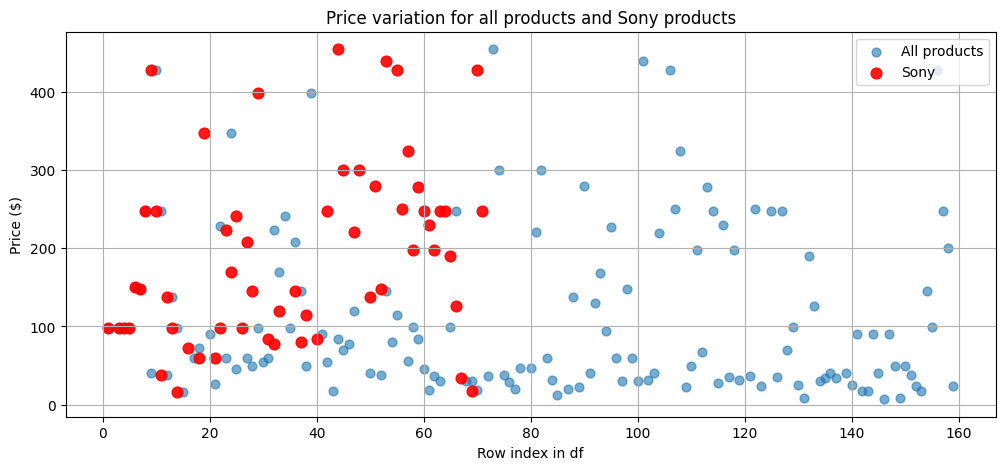

In [59]:
import matplotlib.pyplot as plt

# use original dataframe indices so both series align to df row positions
all_idx = df.dropna(subset=['Price']).index
all_prices = df.loc[all_idx, 'Price']

sony_idx = df_sony.dropna(subset=['Price']).index
sony_prices = df_sony.loc[sony_idx, 'Price']

plt.figure(figsize=(12,5))
plt.scatter(all_idx, all_prices, alpha=0.6, s=40, label='All products')
plt.scatter(sony_idx, sony_prices, alpha=0.9, s=60, color='red', label='Sony')
plt.xlabel('Row index in df')
plt.ylabel('Price ($)')
plt.title('Price variation for all products and Sony products')
plt.legend()
plt.grid(True)
plt.show()

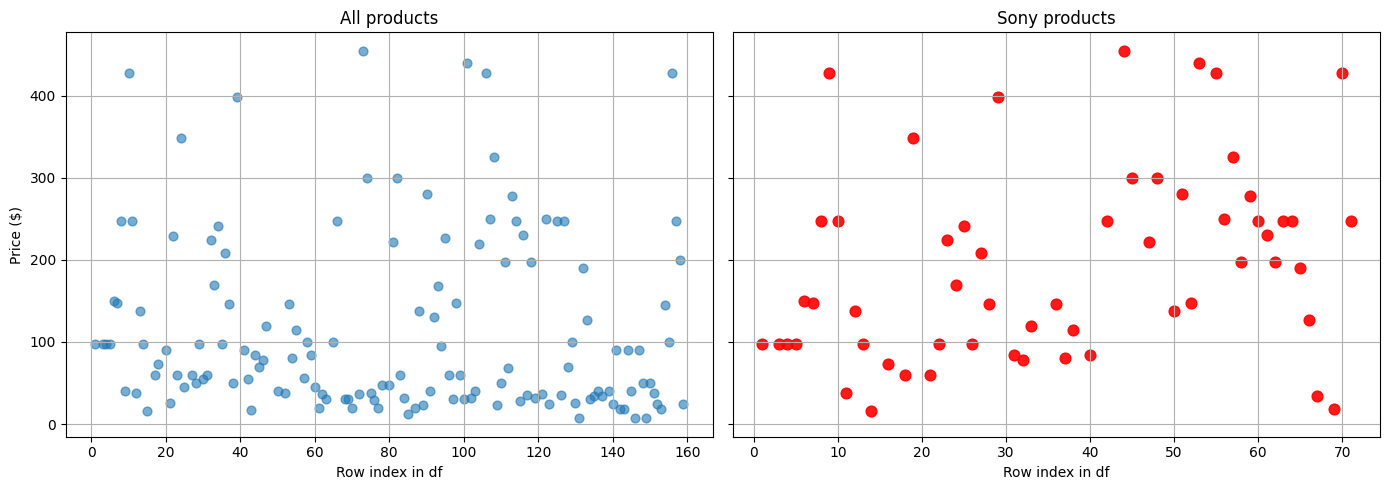

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(all_idx, all_prices, alpha=0.6, s=40)
axes[0].set_title('All products')
axes[0].set_xlabel('Row index in df')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True)

axes[1].scatter(sony_idx, sony_prices, color='red', alpha=0.9, s=60)
axes[1].set_title('Sony products')
axes[1].set_xlabel('Row index in df')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [62]:
high_price = df[df["Price"].gt(400)].sort_values("Price", ascending=False).reset_index(drop=True)
display(high_price)

,title,rating,number of reviews,Price,page,source
0,Sony,4.9,14.0,454.95,5,Amazon
1,Sony,4.5,630.0,439.86,7,Amazon
2,Sony,4.3,2600.0,428.00,1,Amazon
3,Sony,4.4,9.0,428.00,7,Amazon
4,Sony,4.4,9.0,428.00,10,Amazon


rows with both Price and rating: 5
Pearson correlation: 0.9663
Spearman correlation: 0.9177


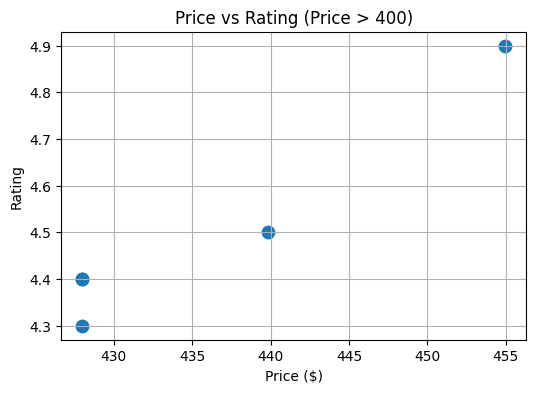

In [64]:
# analyze relation between price and rating for items in `high_price`
df_hp = high_price.dropna(subset=['Price', 'rating']).copy()
print("rows with both Price and rating:", len(df_hp))

if len(df_hp) > 1:
    pearson = df_hp['Price'].corr(df_hp['rating'], method='pearson')
    spearman = df_hp['Price'].corr(df_hp['rating'], method='spearman')
    print(f"Pearson correlation: {pearson:.4f}")
    print(f"Spearman correlation: {spearman:.4f}")
else:
    print("Not enough non-null rows to compute correlations.")

# scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df_hp['Price'], df_hp['rating'], s=80)
plt.xlabel('Price ($)')
plt.ylabel('Rating')
plt.title('Price vs Rating (Price > 400)')
plt.grid(True)
plt.show()

In [ ]:
num_rows_with_nulls = df.isnull().any(axis=1).sum()
print(num_rows_with_nulls)
print(df.shape)



23
(160, 6)


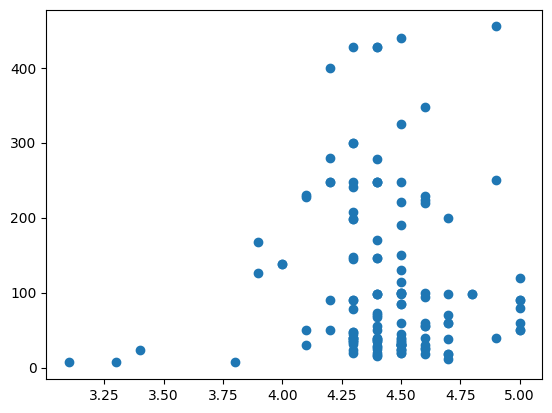

In [66]:
plt.scatter(df["rating"], df["Price"])